In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv("prolixon project data.csv")
df.head()


,Project_ID,Project_Type,Technology,Client_Country,Client_Type,Project_Cost_USD,Project_Duration_Days,Team_Size,Start_Date,End_Date
0,1,Dynamic Website,React,USA,Startup,6956,107,10,18-02-2023,05-06-2023
1,2,Static Website,.NET,Canada,Startup,8629,32,7,18-02-2024,21-03-2024
2,3,E-commerce,Django,Canada,Enterprise,19680,166,4,08-03-2023,21-08-2023
3,4,E-commerce,HTML/CSS/JS,Germany,Enterprise,15521,48,3,06-08-2022,23-09-2022
4,5,Web Application,HTML/CSS/JS,UK,Enterprise,15769,32,6,25-11-2023,27-12-2023


In [4]:
df.shape


(1000, 10)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Project_ID             1000 non-null   int64 
 1   Project_Type           1000 non-null   object
 2   Technology             1000 non-null   object
 3   Client_Country         1000 non-null   object
 4   Client_Type            1000 non-null   object
 5   Project_Cost_USD       1000 non-null   int64 
 6   Project_Duration_Days  1000 non-null   int64 
 7   Team_Size              1000 non-null   int64 
 8   Start_Date             1000 non-null   object
 9   End_Date               1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [6]:
df.describe()


,Project_ID,Project_Cost_USD,Project_Duration_Days,Team_Size
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,12497.772000,94.334000,5.653000
std,288.819436,7155.475598,48.581525,2.847226
min,1.000000,410.000000,10.000000,1.000000
25%,250.750000,6220.250000,53.000000,3.000000
50%,500.500000,12055.000000,93.000000,6.000000
75%,750.250000,18775.250000,135.000000,8.000000
max,1000.000000,24972.000000,180.000000,10.000000


In [7]:
df.isnull().sum()


Project_ID               0
Project_Type             0
Technology               0
Client_Country           0
Client_Type              0
Project_Cost_USD         0
Project_Duration_Days    0
Team_Size                0
Start_Date               0
End_Date                 0
dtype: int64

# data cleaning

In [8]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'], dayfirst=True)
df['End_Date']   = pd.to_datetime(df['End_Date'], dayfirst=True)


In [9]:
df.duplicated().sum()


np.int64(0)

# Exploratory Data Analysis (EDA)

1️⃣ Project Type vs Revenue (Bar chart)

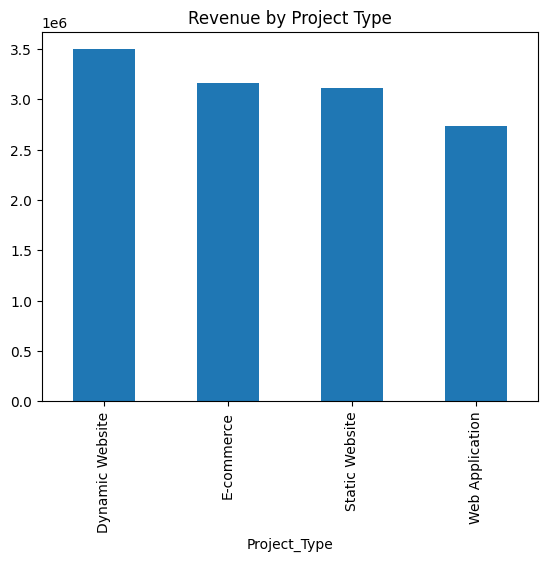

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

project_revenue = df.groupby('Project_Type')['Project_Cost_USD'].sum()

project_revenue.plot(kind='bar')
plt.title("Revenue by Project Type")
plt.show()


2️⃣ Technology Usage (pie chart)

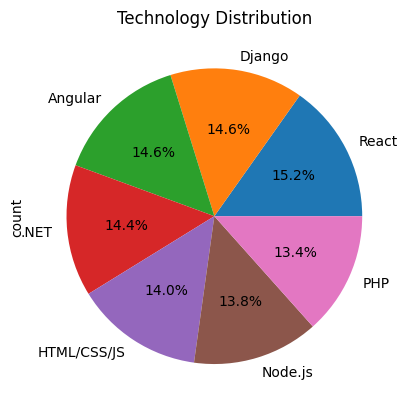

In [11]:
df['Technology'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Technology Distribution")
plt.show()


3️⃣ Team Size vs Project Cost(scatterplot)

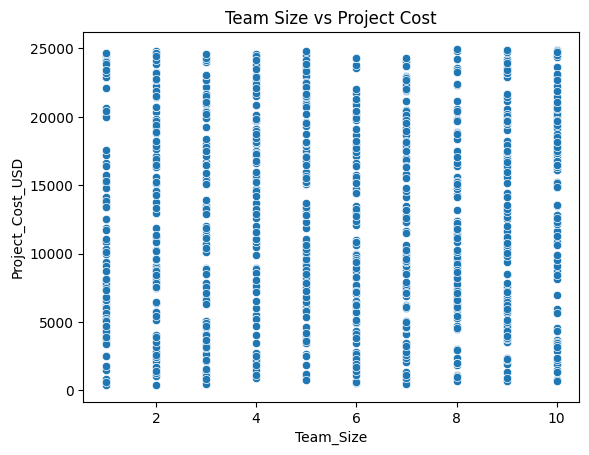

In [12]:
sns.scatterplot(x='Team_Size', y='Project_Cost_USD', data=df)
plt.title("Team Size vs Project Cost")
plt.show()


4️⃣ Monthly Revenue Trend(line graph)

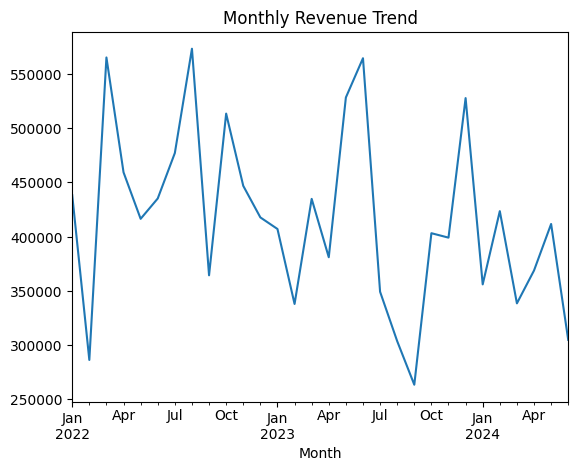

In [13]:
df['Month'] = df['Start_Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Project_Cost_USD'].sum()

monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.show()


🔟 Project Duration Analysis(Bar chart)

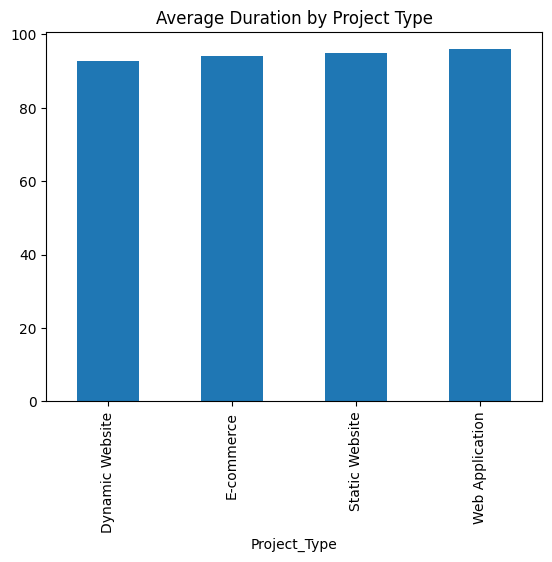

In [14]:
duration = df.groupby('Project_Type')['Project_Duration_Days'].mean()
duration.plot(kind='bar')
plt.title("Average Duration by Project Type")
plt.show()


## Conclusion

This project analyzed internal project data of a web development company.
The analysis identified revenue patterns, technology demand, and operational trends.
These insights can help management in strategic decision making and resource planning.
